In [4]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


In [5]:
#importing the csv file
df = pd.read_csv('sfs_helpdesk_tickets.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (2000, 35)

Columns:
['ticket_id', 'created_date', 'department', 'department_id', 'category', 'category_id', 'priority', 'priority_id', 'status', 'channel', 'channel_id', 'assigned_agent', 'customer_age', 'description', 'suggested_solution', 'ticket_volume_per_hour', 'avg_response_time_mins', 'resolution_time_mins', 'sla_breach', 'reassignment_count', 'hour_of_day', 'day_of_week', 'agent_workload_score', 'ticket_reopen_count', 'message_count', 'escalated', 'satisfaction_score', 'sentiment', 'time_to_first_escalation_mins', 'num_attachments', 'is_weekend', 'previous_tickets_by_customer', 'knowledge_base_used', 'auto_categorized', 'duplicate_flag']

First 3 rows:


,ticket_id,created_date,department,department_id,category,category_id,priority,priority_id,status,channel,...,escalated,satisfaction_score,sentiment,time_to_first_escalation_mins,num_attachments,is_weekend,previous_tickets_by_customer,knowledge_base_used,auto_categorized,duplicate_flag
0,TKT-00001,3/17/2024 0:00,HR,3,Payment Problem,2,LOW,1,CLOSED,Portal,...,0,5.0,POSITIVE,0,2,1,6,1,1,0
1,TKT-00002,1/18/2024 1:00,IT Support,1,Library Access,5,LOW,1,REOPENED,Email,...,1,NaN,NEGATIVE,35,0,0,11,0,0,0
2,TKT-00003,7/6/2024 18:00,Academic Affairs,4,Timetable Issue,8,HIGH,3,RESOLVED,Portal,...,0,4.0,POSITIVE,0,0,1,3,1,0,0


In [6]:
#pre processing

drop_cols = [
    'ticket_id', 'created_date', 'department', 'category',
    'priority', 'status', 'channel', 'assigned_agent',
    'sentiment', 'description', 'suggested_solution'
]

df_model = df.drop(columns=drop_cols)

# Fill missing values
df_model['satisfaction_score'] = df_model['satisfaction_score'].fillna(
    df_model['satisfaction_score'].median()
)
df_model['time_to_first_escalation_mins'] = df_model['time_to_first_escalation_mins'].fillna(0)

print("Data types:")
print(df_model.dtypes)
print(f"\nMissing values:\n{df_model.isnull().sum()}")
print(f"\nFinal training features ({len(df_model.columns)}):")
for c in df_model.columns:
    print(f"  - {c}")

Data types:
department_id                      int64
category_id                        int64
priority_id                        int64
channel_id                         int64
customer_age                       int64
ticket_volume_per_hour             int64
avg_response_time_mins             int64
resolution_time_mins               int64
sla_breach                         int64
reassignment_count                 int64
hour_of_day                        int64
day_of_week                        int64
agent_workload_score               int64
ticket_reopen_count                int64
message_count                      int64
escalated                          int64
satisfaction_score               float64
time_to_first_escalation_mins      int64
num_attachments                    int64
is_weekend                         int64
previous_tickets_by_customer       int64
knowledge_base_used                int64
auto_categorized                   int64
duplicate_flag                     int64
dtyp

In [7]:
# scaling data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

print(f"Scaled data shape: {X_scaled.shape}")
print("Scaling complete")

Scaled data shape: (2000, 24)
Scaling complete


In [8]:
# training isolation forest
model = IsolationForest(
    n_estimators=200,
    contamination=0.20,
    max_samples='auto',
    random_state=42,
    verbose=1
)

model.fit(X_scaled)

scores = model.decision_function(X_scaled)
predictions = model.predict(X_scaled)

df['anomaly_score'] = scores
df['predicted'] = predictions
df['predicted_label'] = df['predicted'].map({1: 'NORMAL', -1: 'ANOMALY'})

total = len(df)
detected = (predictions == -1).sum()
print(f"\nTotal tickets: {total}")
print(f"Detected anomalies: {detected} ({detected/total*100:.1f}%)")
print(f"Normal tickets: {total - detected}")


Total tickets: 2000
Detected anomalies: 400 (20.0%)
Normal tickets: 1600


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.1s finished


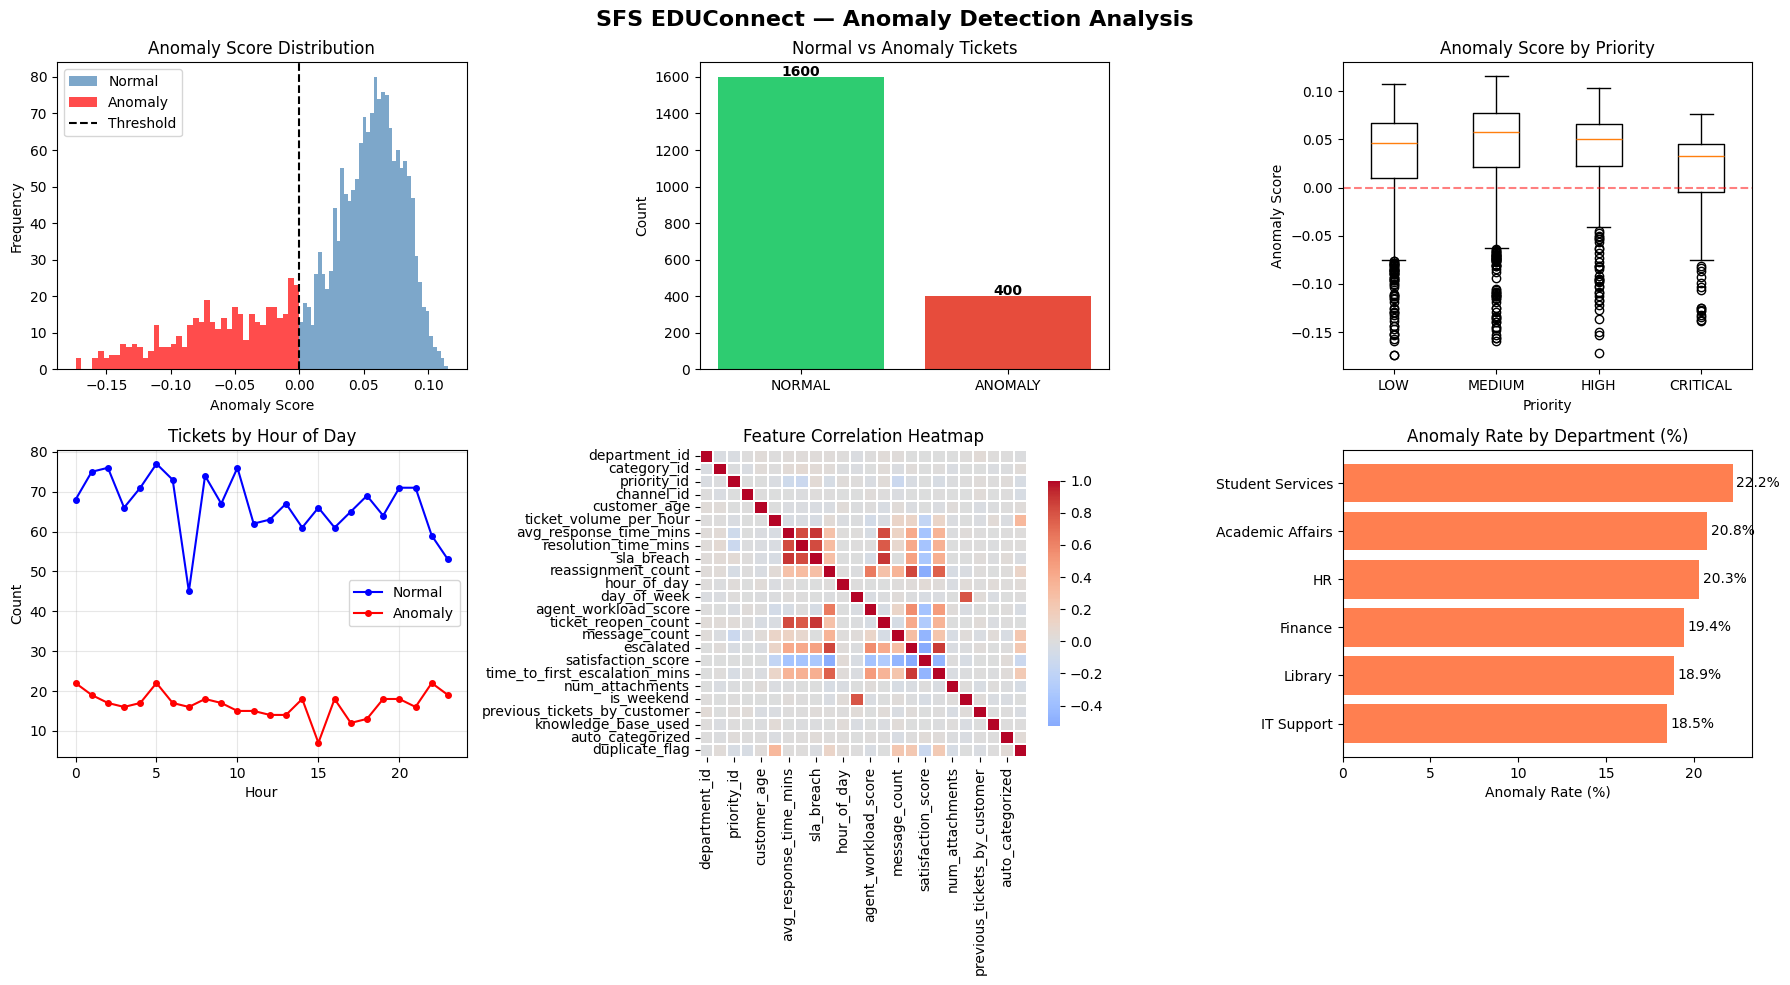

done


In [9]:
# evaluation using graphs
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SFS EDUConnect — Anomaly Detection Analysis', fontsize=16, fontweight='bold')

# G1- Anomaly score distribution
axes[0,0].hist(scores[predictions==1],  bins=40, alpha=0.7, color='steelblue', label='Normal')
axes[0,0].hist(scores[predictions==-1], bins=40, alpha=0.7, color='red',       label='Anomaly')
axes[0,0].axvline(x=0, color='black', linestyle='--', label='Threshold')
axes[0,0].set_title('Anomaly Score Distribution')
axes[0,0].set_xlabel('Anomaly Score')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# G2- Predicted label counts
pred_counts = df['predicted_label'].value_counts()
axes[0,1].bar(pred_counts.index, pred_counts.values,
              color=['#2ecc71', '#e74c3c'])
axes[0,1].set_title('Normal vs Anomaly Tickets')
axes[0,1].set_ylabel('Count')
for i, v in enumerate(pred_counts.values):
    axes[0,1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# G3- Anomaly score by priority
priority_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
data_by_priority = [df[df['priority']==p]['anomaly_score'].values for p in priority_order]
axes[0,2].boxplot(data_by_priority, labels=priority_order)
axes[0,2].set_title('Anomaly Score by Priority')
axes[0,2].set_xlabel('Priority')
axes[0,2].set_ylabel('Anomaly Score')
axes[0,2].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# G4- Anomalies by hour of day
hourly_anomalies = df[df['predicted']==-1].groupby('hour_of_day').size()
hourly_normal    = df[df['predicted']==1].groupby('hour_of_day').size()
axes[1,0].plot(hourly_normal.index,    hourly_normal.values,    'b-o', label='Normal',  markersize=4)
axes[1,0].plot(hourly_anomalies.index, hourly_anomalies.values, 'r-o', label='Anomaly', markersize=4)
axes[1,0].set_title('Tickets by Hour of Day')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# G5- Feature correlation heatmap
corr = df_model.corr()
sns.heatmap(corr, ax=axes[1,1], cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, cbar_kws={'shrink': 0.8})
axes[1,1].set_title('Feature Correlation Heatmap')

# G6- Anomaly rate by department
dept_stats = df.groupby('department').apply(
    lambda x: (x['predicted']==-1).sum() / len(x) * 100
).sort_values(ascending=True)
axes[1,2].barh(dept_stats.index, dept_stats.values, color='coral')
axes[1,2].set_title('Anomaly Rate by Department (%)')
axes[1,2].set_xlabel('Anomaly Rate (%)')
for i, v in enumerate(dept_stats.values):
    axes[1,2].text(v + 0.2, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.savefig('anomaly_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("done")

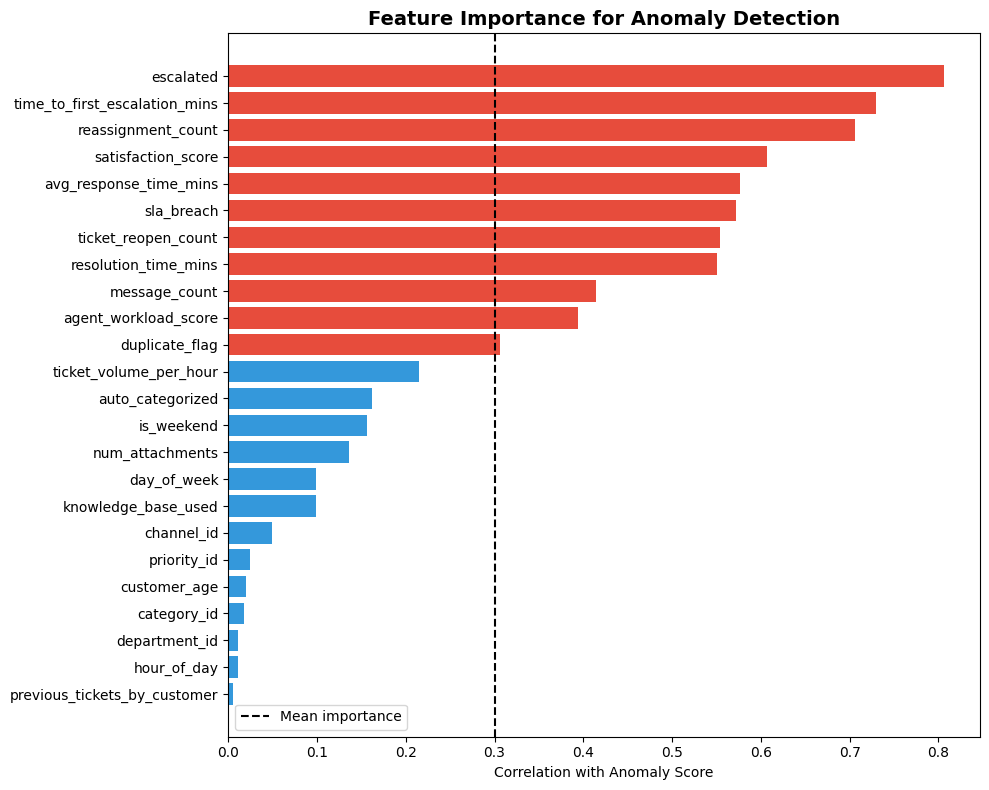


Top 5 most important features:
                          feature  importance
15                      escalated      0.8066
17  time_to_first_escalation_mins      0.7301
9              reassignment_count      0.7056
16             satisfaction_score      0.6075
6          avg_response_time_mins      0.5760


In [10]:
# feature importance
feature_names = df_model.columns.tolist()

importances = []
for i, feat in enumerate(feature_names):
    corr = abs(np.corrcoef(df_model[feat], scores)[0,1])
    importances.append({'feature': feat, 'importance': round(corr, 4)})

fi_df = pd.DataFrame(importances).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > fi_df['importance'].mean()
          else '#3498db' for x in fi_df['importance']]
plt.barh(fi_df['feature'], fi_df['importance'], color=colors)
plt.axvline(x=fi_df['importance'].mean(), color='black',
            linestyle='--', label='Mean importance')
plt.title('Feature Importance for Anomaly Detection', fontsize=14, fontweight='bold')
plt.xlabel('Correlation with Anomaly Score')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(fi_df.sort_values('importance', ascending=False).head())

MODEL ACCURACY REPORT

Total tickets:        2000
True anomalies:       368
Predicted anomalies:  400

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.96      0.96      1632
     Anomaly       0.82      0.89      0.85       368

    accuracy                           0.94      2000
   macro avg       0.90      0.92      0.91      2000
weighted avg       0.95      0.94      0.94      2000



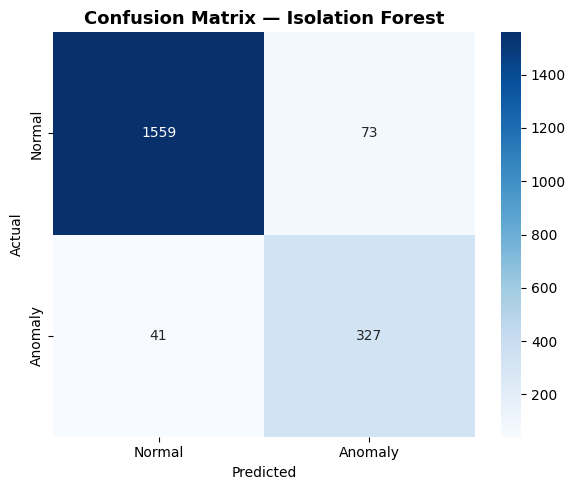


Overall Accuracy: 94.30%


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# simple rule-based ground truth from the data
y_true = (
    (df['resolution_time_mins'] > df['resolution_time_mins'].quantile(0.90)) |
    (df['agent_workload_score'] > df['agent_workload_score'].quantile(0.90)) |
    (df['reassignment_count'] > df['reassignment_count'].quantile(0.90)) |
    (df['ticket_reopen_count'] > 1) |
    (df['sla_breach'] == 1) |
    (df['escalated'] == 1)
).astype(int)

y_pred = (df['predicted'] == -1).astype(int)

print("=" * 50)
print("MODEL ACCURACY REPORT")
print("=" * 50)
print(f"\nTotal tickets:        {len(df)}")
print(f"True anomalies:       {y_true.sum()}")
print(f"Predicted anomalies:  {y_pred.sum()}")
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred,
      target_names=['Normal', 'Anomaly']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Confusion Matrix — Isolation Forest', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Overall accuracy
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_true, y_pred)
print(f"\nOverall Accuracy: {acc*100:.2f}%")

In [13]:
# tuning hyper parameters

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score
import numpy as np

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'contamination': [0.15, 0.18, 0.20, 0.22],
    'max_samples': [256, 512, 'auto'],
    'max_features': [0.8, 1.0]
}

best_score = 0
best_params = {}
best_model = None

print("Tuning hyperparameters...")
print("=" * 50)

for params in ParameterGrid(param_grid):
    m = IsolationForest(
        n_estimators=params['n_estimators'],
        contamination=params['contamination'],
        max_samples=params['max_samples'],
        max_features=params['max_features'],
        random_state=42
    )
    m.fit(X_scaled)
    preds = m.predict(X_scaled)
    y_p = (preds == -1).astype(int)

    score = f1_score(y_true, y_p, average='weighted')

    if score > best_score:
        best_score = score
        best_params = params
        best_model = m

print(f"Best F1 Score: {best_score*100:.2f}%")
print(f"Best Parameters: {best_params}")

# Evaluate best model
best_preds = best_model.predict(X_scaled)
best_scores = best_model.decision_function(X_scaled)
y_pred_best = (best_preds == -1).astype(int)

from sklearn.metrics import accuracy_score
print(f"\nBest Model Accuracy: {accuracy_score(y_true, y_pred_best)*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred_best,
      target_names=['Normal', 'Anomaly']))

Tuning hyperparameters...
Best F1 Score: 95.68%
Best Parameters: {'contamination': 0.18, 'max_features': 0.8, 'max_samples': 512, 'n_estimators': 100}

Best Model Accuracy: 95.70%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97      1632
     Anomaly       0.89      0.87      0.88       368

    accuracy                           0.96      2000
   macro avg       0.93      0.92      0.93      2000
weighted avg       0.96      0.96      0.96      2000



In [15]:
joblib.dump(model,  'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved!")

from google.colab import files
files.download('model.pkl')
files.download('scaler.pkl')
files.download('anomaly_analysis.png')
files.download('feature_importance.png')

Model and scaler saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>